## Yellow-legged hornet model

11 - Patch construction

12 - Grid Search

13 - PSO

14 - Simulation

**15 - Map**

Spatial Division 1

 Region 1: France

 Region 2: others

**Spatial Division 2**

 Region 1: France _+ Portugal

 Region 2: others


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import os
import zipfile
import warnings
import matplotlib as mpl

In [ ]:
gpkg = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/" "hornet_plot_layers_FRPT.gpkg")

patches = gpd.read_file(gpkg, layer="patches")
land = gpd.read_file(gpkg, layer="land")
water = gpd.read_file(gpkg, layer="water")
countries = gpd.read_file(gpkg, layer="countries")
study_area = gpd.read_file(gpkg, layer="study_area")

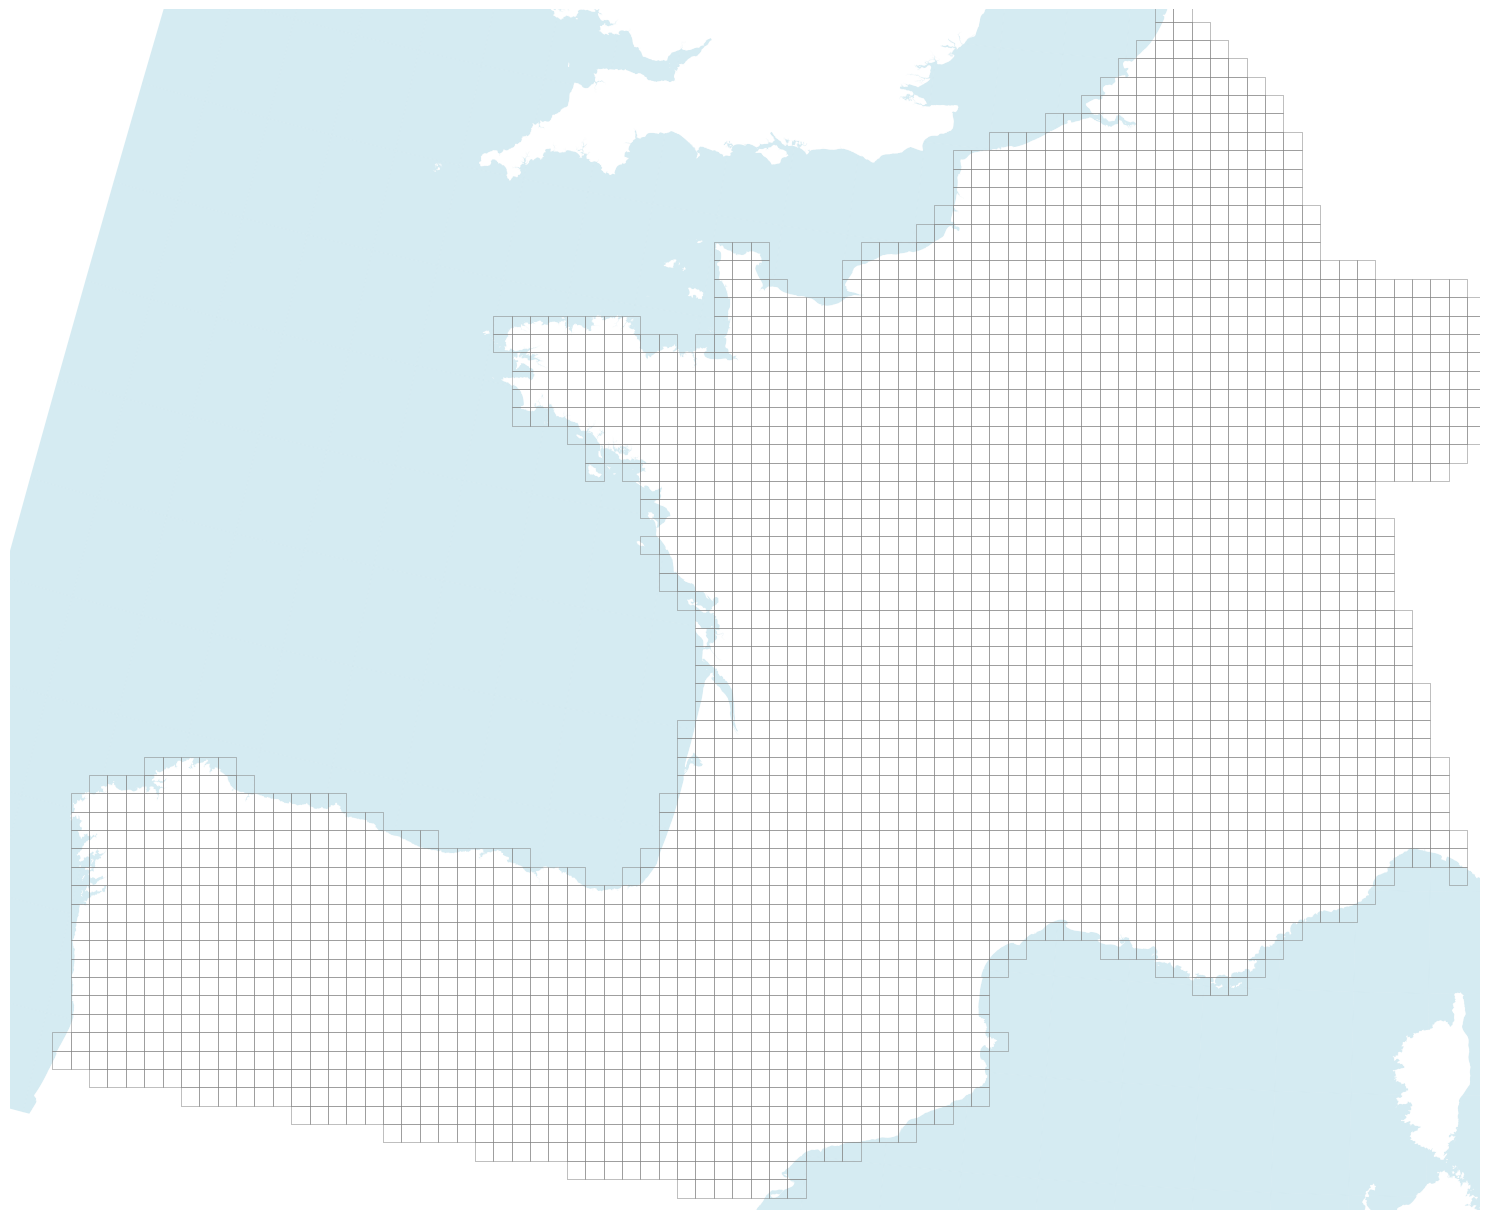

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))

water.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="none",
    alpha=0.5,
    zorder=1
)

land.plot(
    ax=ax,
    facecolor="white",
    edgecolor="none",
    alpha=0.5,
    zorder=2
)

patches.boundary.plot(
    ax=ax,
    color="grey",
    alpha=0.6,
    linewidth=0.6,
    zorder=3
)

# countries.boundary.plot(
#     ax=ax,
#     color="black",
#     linewidth=0.6,
#     alpha=0.5,
#     zorder=4
# )

xmin, ymin, xmax, ymax = study_area.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal")
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
patches.head()

,patch_id,cell_area,land_area,land_prop,occyear1,occyear2,land_centroid,A_i,region,geometry
0,0,400000000.0,1.796594e+08,0.449148,0,0,POINT (2755966.134143 2156580.001893),179.659369,1,"POLYGON ((2760998.39 2148583.113, 2760998.39 2..."
1,1,400000000.0,3.588828e+08,0.897207,0,0,POINT (2751923.621122 2137986.612305),358.882792,1,"POLYGON ((2760998.39 2128583.113, 2760998.39 2..."
2,2,400000000.0,2.328088e+08,0.582022,1,1,POINT (2774165.538482 2416511.727893),232.808759,2,"POLYGON ((2780998.39 2408583.113, 2780998.39 2..."
3,3,400000000.0,2.426348e+08,0.606587,1,1,POINT (2773988.511772 2400306.671631),242.634810,2,"POLYGON ((2780998.39 2388583.113, 2780998.39 2..."
4,4,400000000.0,1.125199e+08,0.281300,1,1,POINT (2776348.142842 2379904.065578),112.519858,2,"POLYGON ((2780998.39 2368583.113, 2780998.39 2..."


In [ ]:
patches = gpd.read_file(
    gpkg,
    layer="patches"
)

display(patches.drop(columns="geometry").head())

,patch_id,cell_area,land_area,land_prop,occyear1,occyear2,land_centroid,A_i,region
0,0,400000000.0,1.796594e+08,0.449148,0,0,POINT (2755966.134143 2156580.001893),179.659369,1
1,1,400000000.0,3.588828e+08,0.897207,0,0,POINT (2751923.621122 2137986.612305),358.882792,1
2,2,400000000.0,2.328088e+08,0.582022,1,1,POINT (2774165.538482 2416511.727893),232.808759,2
3,3,400000000.0,2.426348e+08,0.606587,1,1,POINT (2773988.511772 2400306.671631),242.634810,2
4,4,400000000.0,1.125199e+08,0.281300,1,1,POINT (2776348.142842 2379904.065578),112.519858,2


In [ ]:
summary_patch_gs_d2 = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d2_gs_deter.csv"
)

map_gs_d2 = patches.merge(summary_patch_gs_d2, on="patch_id",
    how="left",
    validate="one_to_many"
)

print(map_gs_d2.shape)
print(map_gs_d2["year"].unique())

(51340, 17)
[2020 2030 2040 2050 2060 2070 2080 2090 2100 2110 2120 2130 2140 2150
 2160 2170 2180 2190 2200 2210]


In [ ]:
# regional boundaries

region_boundaries = (
    patches[
        patches["region"].isin([1, 2])
    ]
    .dissolve(by="region")
)

region_boundaries

,geometry,patch_id,cell_area,land_area,land_prop,occyear1,occyear2,land_centroid,A_i
region,,,,,,,,,
1,"MULTIPOLYGON (((2780998.39 2108583.113, 278099...",0,400000000.0,1.796594e+08,0.449148,0,0,POINT (2755966.134143 2156580.001893),179.659369
2,"MULTIPOLYGON (((2940998.39 2148583.113, 294099...",2,400000000.0,2.328088e+08,0.582022,1,1,POINT (2774165.538482 2416511.727893),232.808759


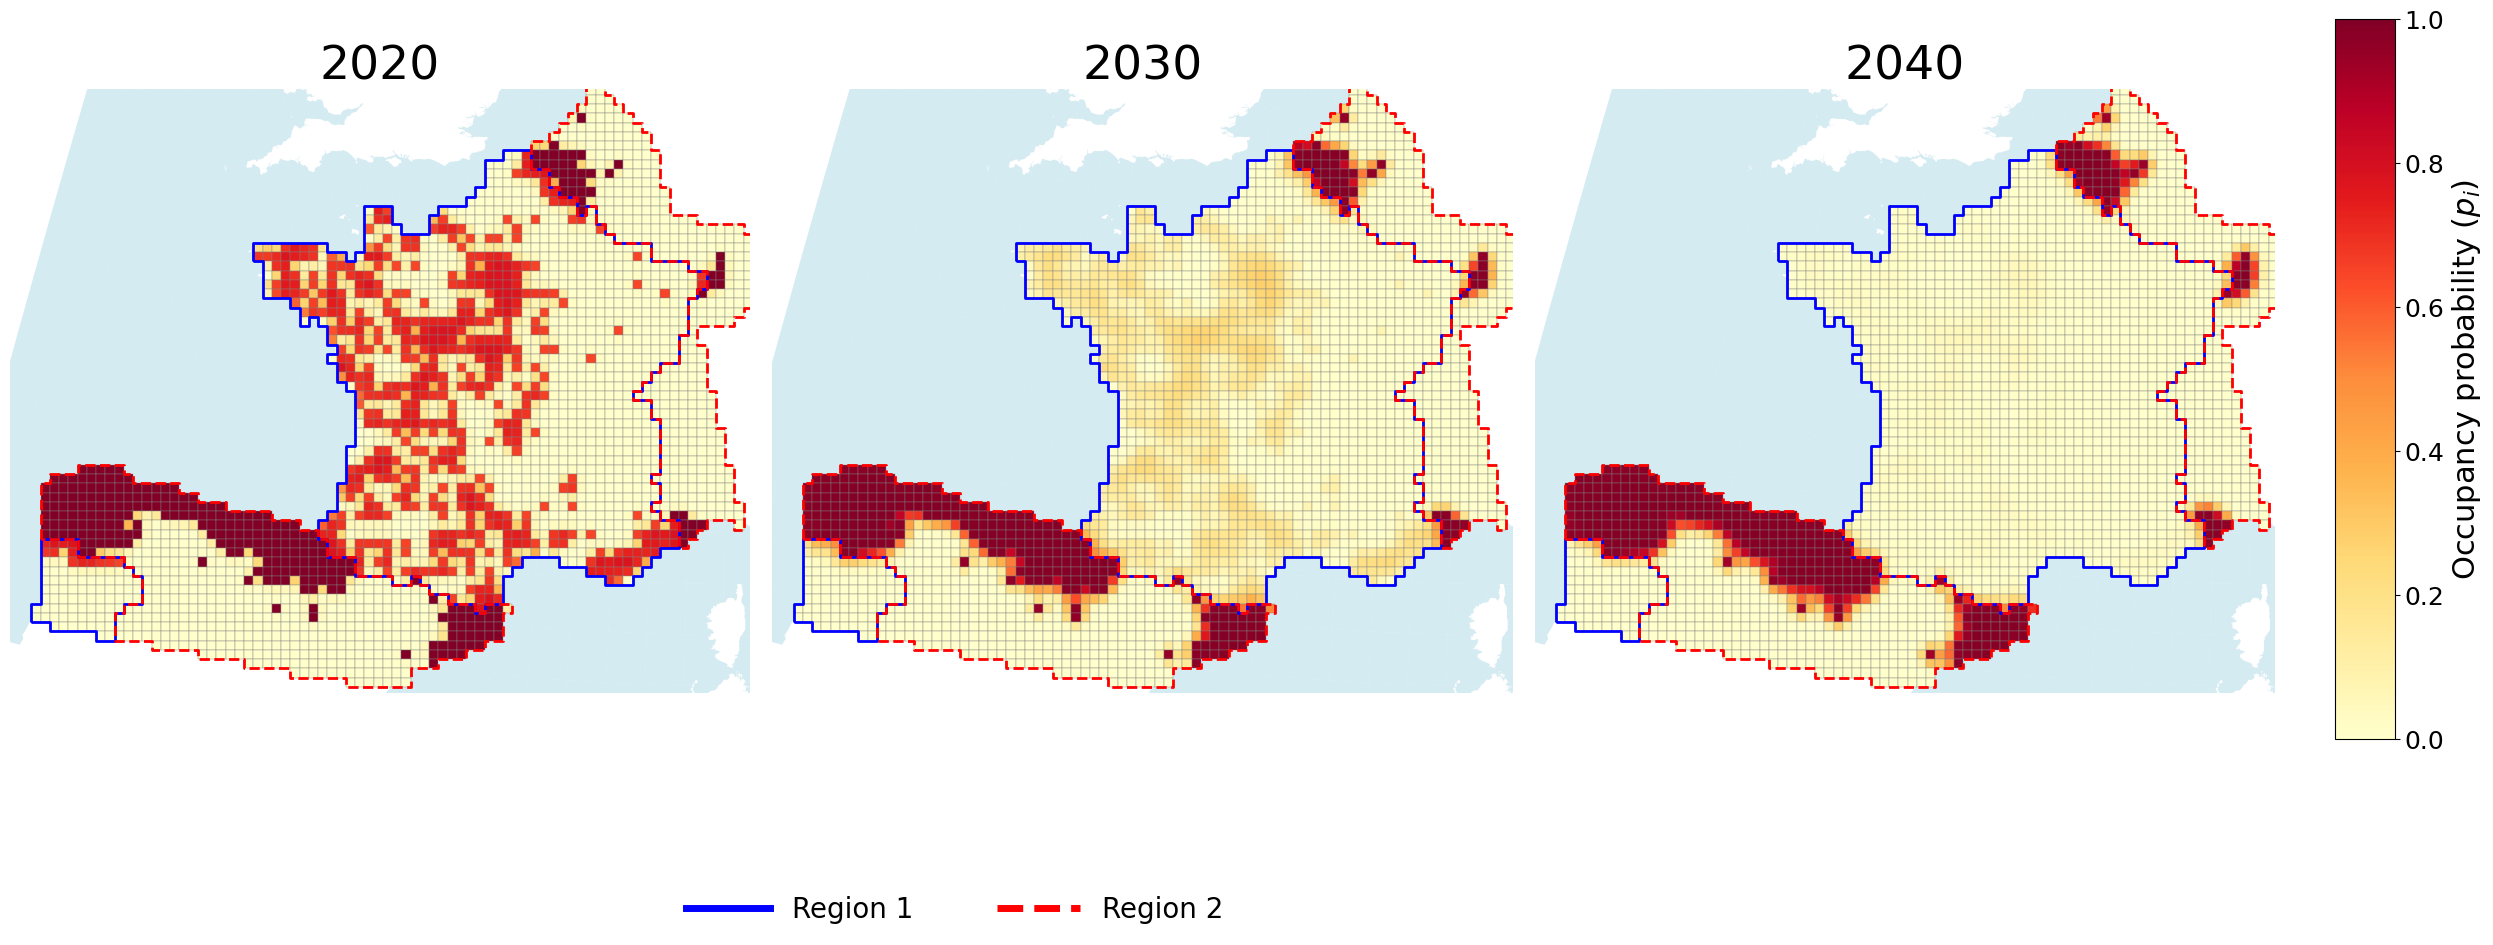

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

years = [2020, 2030, 2040]

# Region boundaries
region_boundaries = (
    patches[
        patches["region"].isin([1, 2])
    ]
    .dissolve(by="region")
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(30, 12)
)

axes = axes.flatten()


xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

for ax, year in zip(axes, years):

    map_year = map_gs_d2[
        map_gs_d2["year"] == year
    ].copy()

    # water background
    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    # land background
    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    # projected occupancy probability
    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.3,
        zorder=3
    )

    # Region 1
    region_boundaries.loc[[1]].boundary.plot(
        ax=ax,
        color="blue",
        linewidth=2,
        zorder=4
    )

    # Region 2
    region_boundaries.loc[[2]].boundary.plot(
        ax=ax,
        color="red",
        linewidth=2,
        linestyle="--",
        zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax.set_title(
        str(year),
        fontsize=34
    )

# leave space on right and bottom
fig.subplots_adjust(
    right=0.88,
    bottom=0.10,
    wspace=0.03,
    hspace=0.03
)

# shared colour bar
sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cax = fig.add_axes([
    0.90,
    0.20,
    0.02,
    0.60
])

cbar = fig.colorbar(
    sm,
    cax=cax
)

cbar.set_label(
    r"Occupancy probability ($p_i$)",
    fontsize=22
)

cbar.ax.tick_params(
    labelsize=18
)

# Region legend
region_legend = [
    Line2D(
        [0], [0],
        color="blue",
        linewidth=5,
        label="Region 1"
    ),

    Line2D(
        [0], [0],
        color="red",
        linewidth=5,
        linestyle="--",
        label="Region 2"
    )
]

fig.legend(
    handles=region_legend,
    loc="lower center",
    bbox_to_anchor=(0.44, 0.025),
    ncol=2,
    prop={"size": 20},
    handlelength=3,
    columnspacing=3,
    frameon=False
)

plt.show()

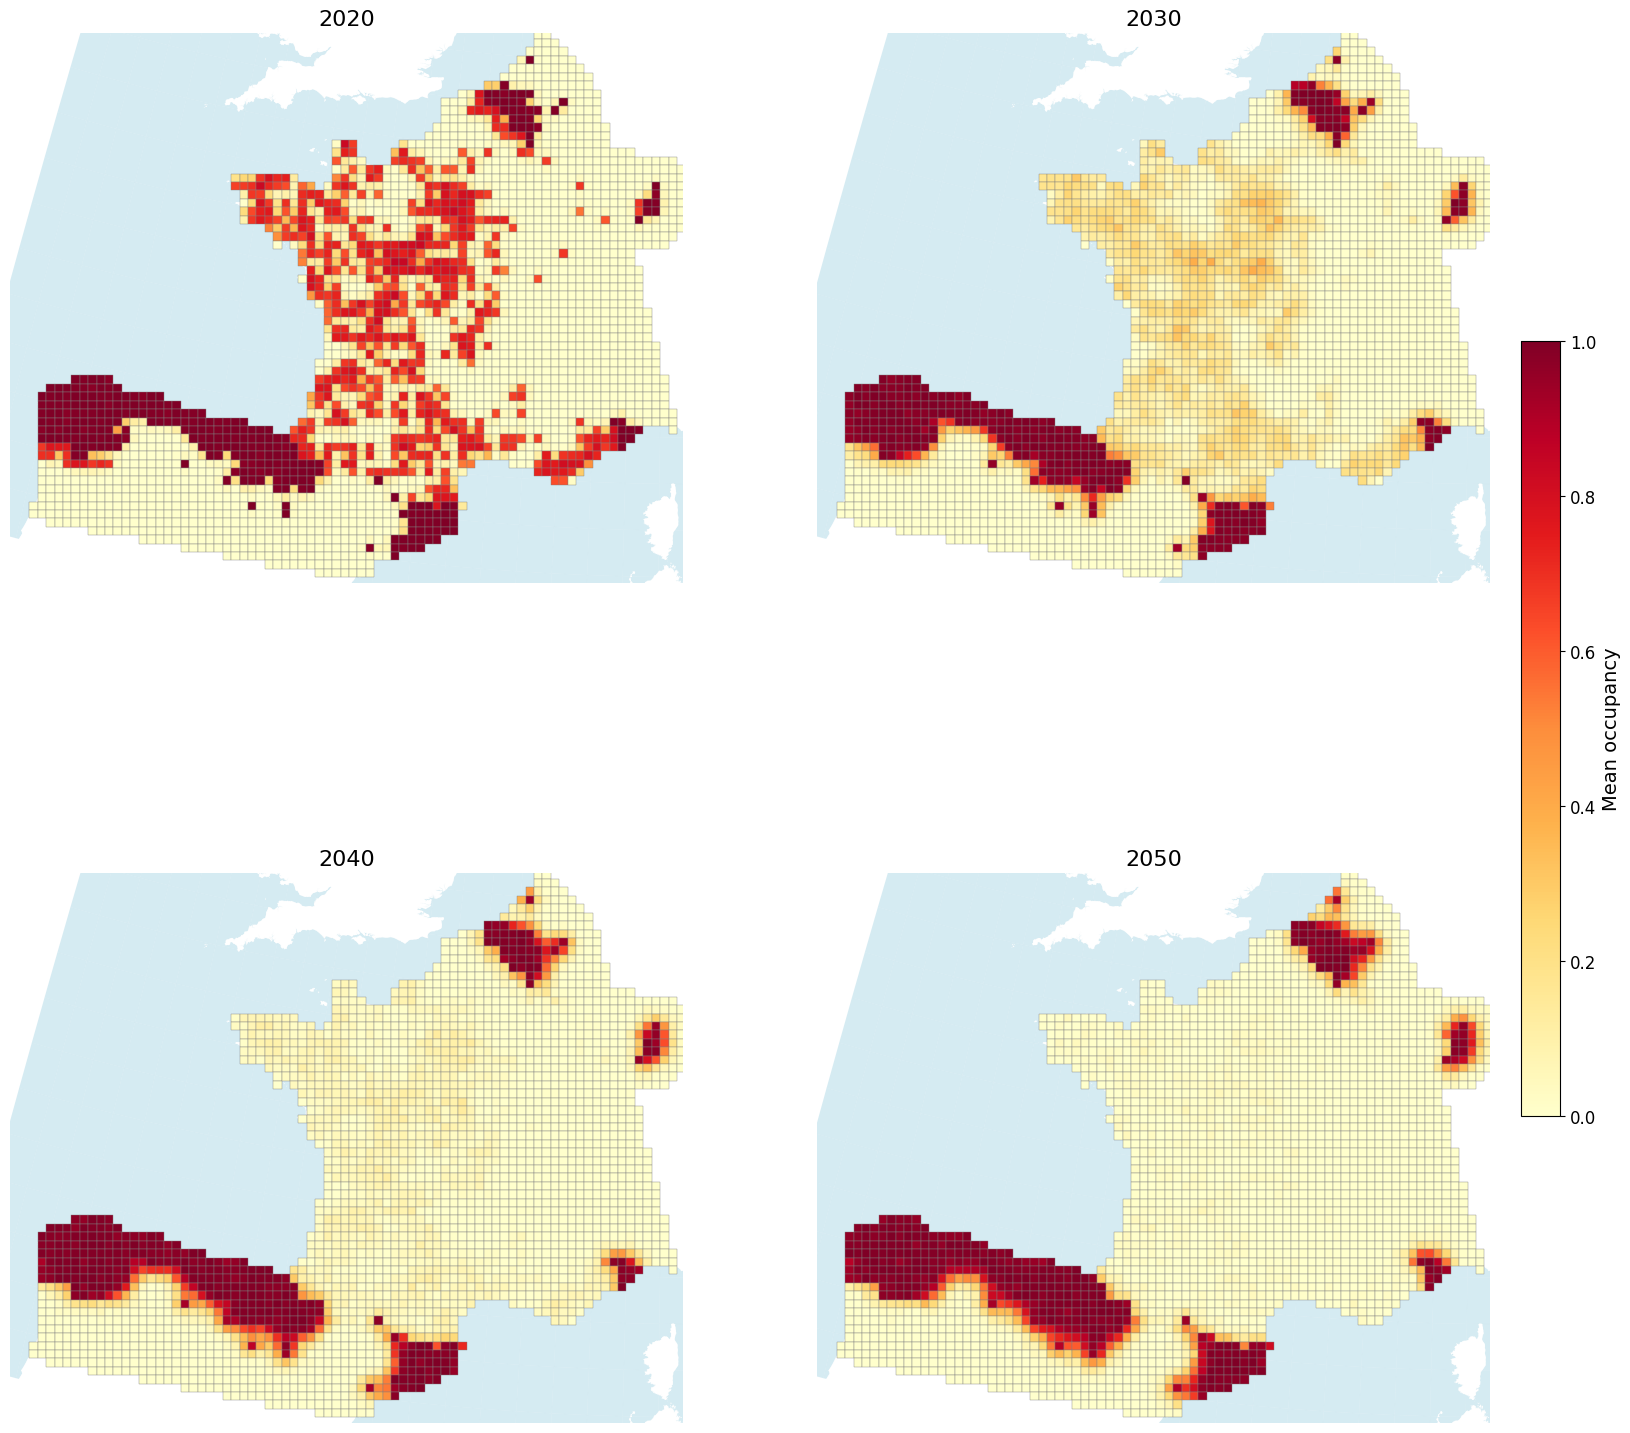

In [ ]:
# years = [2020, 2030, 2040, 2050]

# fig, axes = plt.subplots(
#     2, 2,
#     figsize=(20, 20)
# )

# axes = axes.flatten()

# xmin, ymin, xmax, ymax = study_area.total_bounds

# norm = mpl.colors.Normalize(vmin=0, vmax=1)
# cmap = "YlOrRd"

# for ax, year in zip(axes, years):

#     map_year = map_gs_d2[
#         map_gs_d2["year"] == year
#     ].copy()

#     # water background
#     water.plot(
#         ax=ax,
#         facecolor="lightblue",
#         edgecolor="none",
#         alpha=0.5,
#         zorder=1
#     )

#     # land background
#     land.plot(
#         ax=ax,
#         facecolor="white",
#         edgecolor="none",
#         alpha=0.5,
#         zorder=2
#     )

#     # projected mean occupancy
#     map_year.plot(
#         ax=ax,
#         column="mean_occupancy",
#         cmap=cmap,
#         norm=norm,
#         edgecolor="grey",
#         linewidth=0.3,
#         zorder=3
#     )



#     # Region 1 background
#     region_boundaries.loc[[1]].plot(
#     ax=ax,
#     facecolor="#1f77b4",
#     edgecolor="none",
#     alpha=0.2,
#     zorder=2.5
#     )

#     # Region 2 background
#     region_boundaries.loc[[2]].plot(
#     ax=ax,
#     facecolor="#ff7f0e",
#     edgecolor="none",
#     alpha=0.2,
#     zorder=2.5
#     )



#     ax.set_xlim(xmin, xmax)
#     ax.set_ylim(ymin, ymax)

#     ax.set_aspect("equal")
#     ax.set_axis_off()

#     ax.set_title(
#         str(year),
#         fontsize=16
#     )


# # shared colour bar
# sm = mpl.cm.ScalarMappable(
#     norm=norm,
#     cmap=cmap
# )

# sm.set_array([])

# cbar = fig.colorbar(
#     sm,
#     ax=axes,
#     fraction=0.025,
#     pad=0.02
# )

# cbar.set_label(
#     "Mean occupancy",
#     fontsize=14
# )

# cbar.ax.tick_params(
#     labelsize=12
# )

# plt.show()

In [ ]:
years = sorted(map_gs_d2["year"].unique())

print(years[:10])
print(years[-5:])
print("Number of frames:", len(years))

[np.int64(2020), np.int64(2030), np.int64(2040), np.int64(2050)]
[np.int64(2020), np.int64(2030), np.int64(2040), np.int64(2050)]
Number of frames: 4


In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

# All simulated years
years = sorted(map_gs_d2["year"].unique())

xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

fig, ax = plt.subplots(figsize=(10, 10))


# --------------------------------------------------
# Colour bar
sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.02
)

cbar.set_label(
    "Mean occupancy",
    fontsize=13
)

cbar.ax.tick_params(labelsize=11)


# --------------------------------------------------
# Animation function
def update(year):

    ax.clear()

    map_year = map_gs_d2[
        map_gs_d2["year"] == year
    ]


    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )


    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    # occupancy
    map_year.plot(
        ax=ax,
        column="mean_occupancy",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.25,
        zorder=3
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_aspect("equal")
    ax.set_axis_off()

    ax.set_title(
        f"Yellow-legged hornet projection — {year}",
        fontsize=15
    )


# --------------------------------------------------
# Create animation
animation = FuncAnimation(
    fig,
    update,
    frames=years,
    interval=500,   # milliseconds per frame
    repeat=True
)



gif_path = (
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_GS_D2_projection_deter.gif"
)

animation.save(
    gif_path,
    writer=PillowWriter(fps=3),
    dpi=120
)

plt.close()


Saved: /content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_GS_D2_projection.gif


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display

# --------------------------------------------------
# All simulated years
years = sorted(map_gs_d2["year"].unique())

xmin, ymin, xmax, ymax = study_area.total_bounds
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

fig, ax = plt.subplots(figsize=(10, 10))

# --------------------------------------------------
# Colour bar
sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.02
)
cbar.set_label(
    "Mean occupancy",
    fontsize=13
)
cbar.ax.tick_params(labelsize=11)

# --------------------------------------------------
# Animation function
def update(year):
    ax.clear()

    map_year = map_gs_d2[
        map_gs_d2["year"] == year
    ]

    # water
    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    # land
    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    # occupancy
    map_year.plot(
        ax=ax,
        column="mean_occupancy",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.25,
        zorder=3
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(
        f"Yellow-legged hornet projection — {year}",
        fontsize=15
    )

# --------------------------------------------------
# Create animation
animation = FuncAnimation(
    fig,
    update,
    frames=years,
    interval=2000,  #### time interval!!
    repeat=True
)

# --------------------------------------------------
display(HTML(animation.to_jshtml()))

# --------------------------------------------------
# Save GIF
gif_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_GS_D2_projection.gif")


# fps=0.5 means 1 frame every 2 seconds
animation.save(
    gif_path,
    writer=PillowWriter(fps=0.5),
    dpi=120
)

plt.close(fig)

In [ ]:
################################################################################################################################################################
### PSO

summary_patch_pso_d2 = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d2_pso_deter.csv"
)

map_pso_d2 = patches.merge(summary_patch_pso_d2, on="patch_id",
    how="left",
    validate="one_to_many"
)

print(map_pso_d2.shape)
print(map_pso_d2["year"].unique())

(10268, 29)
[2020 2030 2040 2050]


In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display

# --------------------------------------------------
# All simulated years
years = sorted(map_pso_d2["year"].unique())

xmin, ymin, xmax, ymax = study_area.total_bounds
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

fig, ax = plt.subplots(figsize=(10, 10))

# --------------------------------------------------
# color
sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.02
)
cbar.set_label(
    "Mean occupancy",
    fontsize=13
)
cbar.ax.tick_params(labelsize=11)

# --------------------------------------------------
# Animation function
def update(year):
    ax.clear()

    map_year = map_pso_d2[
        map_pso_d2["year"] == year
    ]

    # water
    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )


    map_year.plot(
        ax=ax,
        column="mean_occupancy",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.25,
        zorder=3
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(
        f"Yellow-legged hornet projection — {year}",
        fontsize=15
    )

# --------------------------------------------------
# Create animation
animation = FuncAnimation(
    fig,
    update,
    frames=years,
    interval=2000,
    repeat=True
)

# --------------------------------------------------
display(HTML(animation.to_jshtml()))

# --------------------------------------------------
# Save gif
gif_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_PSO_D2_projection.gif")


# fps=0.5 means 1 frame every 2 seconds
animation.save(
    gif_path,
    writer=PillowWriter(fps=0.5),
    dpi=120
)

plt.close(fig)

# Case plot


In [ ]:
patch_results_d2_gs_r1_only_deter = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d2_gs_r1_only_deter.csv"
)

map_d2_gs_r1_only = patches.merge(
    patch_results_d2_gs_r1_only_deter,
    on="patch_id",
    how="left",
    validate="one_to_many"
)

print(patch_results_d2_gs_r1_only_deter.shape)
print(patch_results_d2_gs_r1_only_deter.columns)
print(patch_results_d2_gs_r1_only_deter["year"].unique())
print(map_d2_gs_r1_only.shape)
print(map_d2_gs_r1_only["year"].unique())

(51340, 8)
Index(['step', 'year', 'patch_id', 'region', 'E_i', 'S_i', 'C_i', 'p_next'], dtype='object')
[2020 2030 2040 2050 2060 2070 2080 2090 2100 2110 2120 2130 2140 2150
 2160 2170 2180 2190 2200 2210]
(51340, 17)
[2020 2030 2040 2050 2060 2070 2080 2090 2100 2110 2120 2130 2140 2150
 2160 2170 2180 2190 2200 2210]


In [ ]:
map_d2_gs_r1_only.groupby("year")["p_next"].agg(
    ["min", "mean", "max", "std"]
).loc[[2020, 2040, 2060]]

,min,mean,max,std
year,,,,
2020,0.0,0.249559,0.806354,0.321453
2040,0.0,0.011489,0.067329,0.015808
2060,0.0,0.000150,0.001017,0.000219


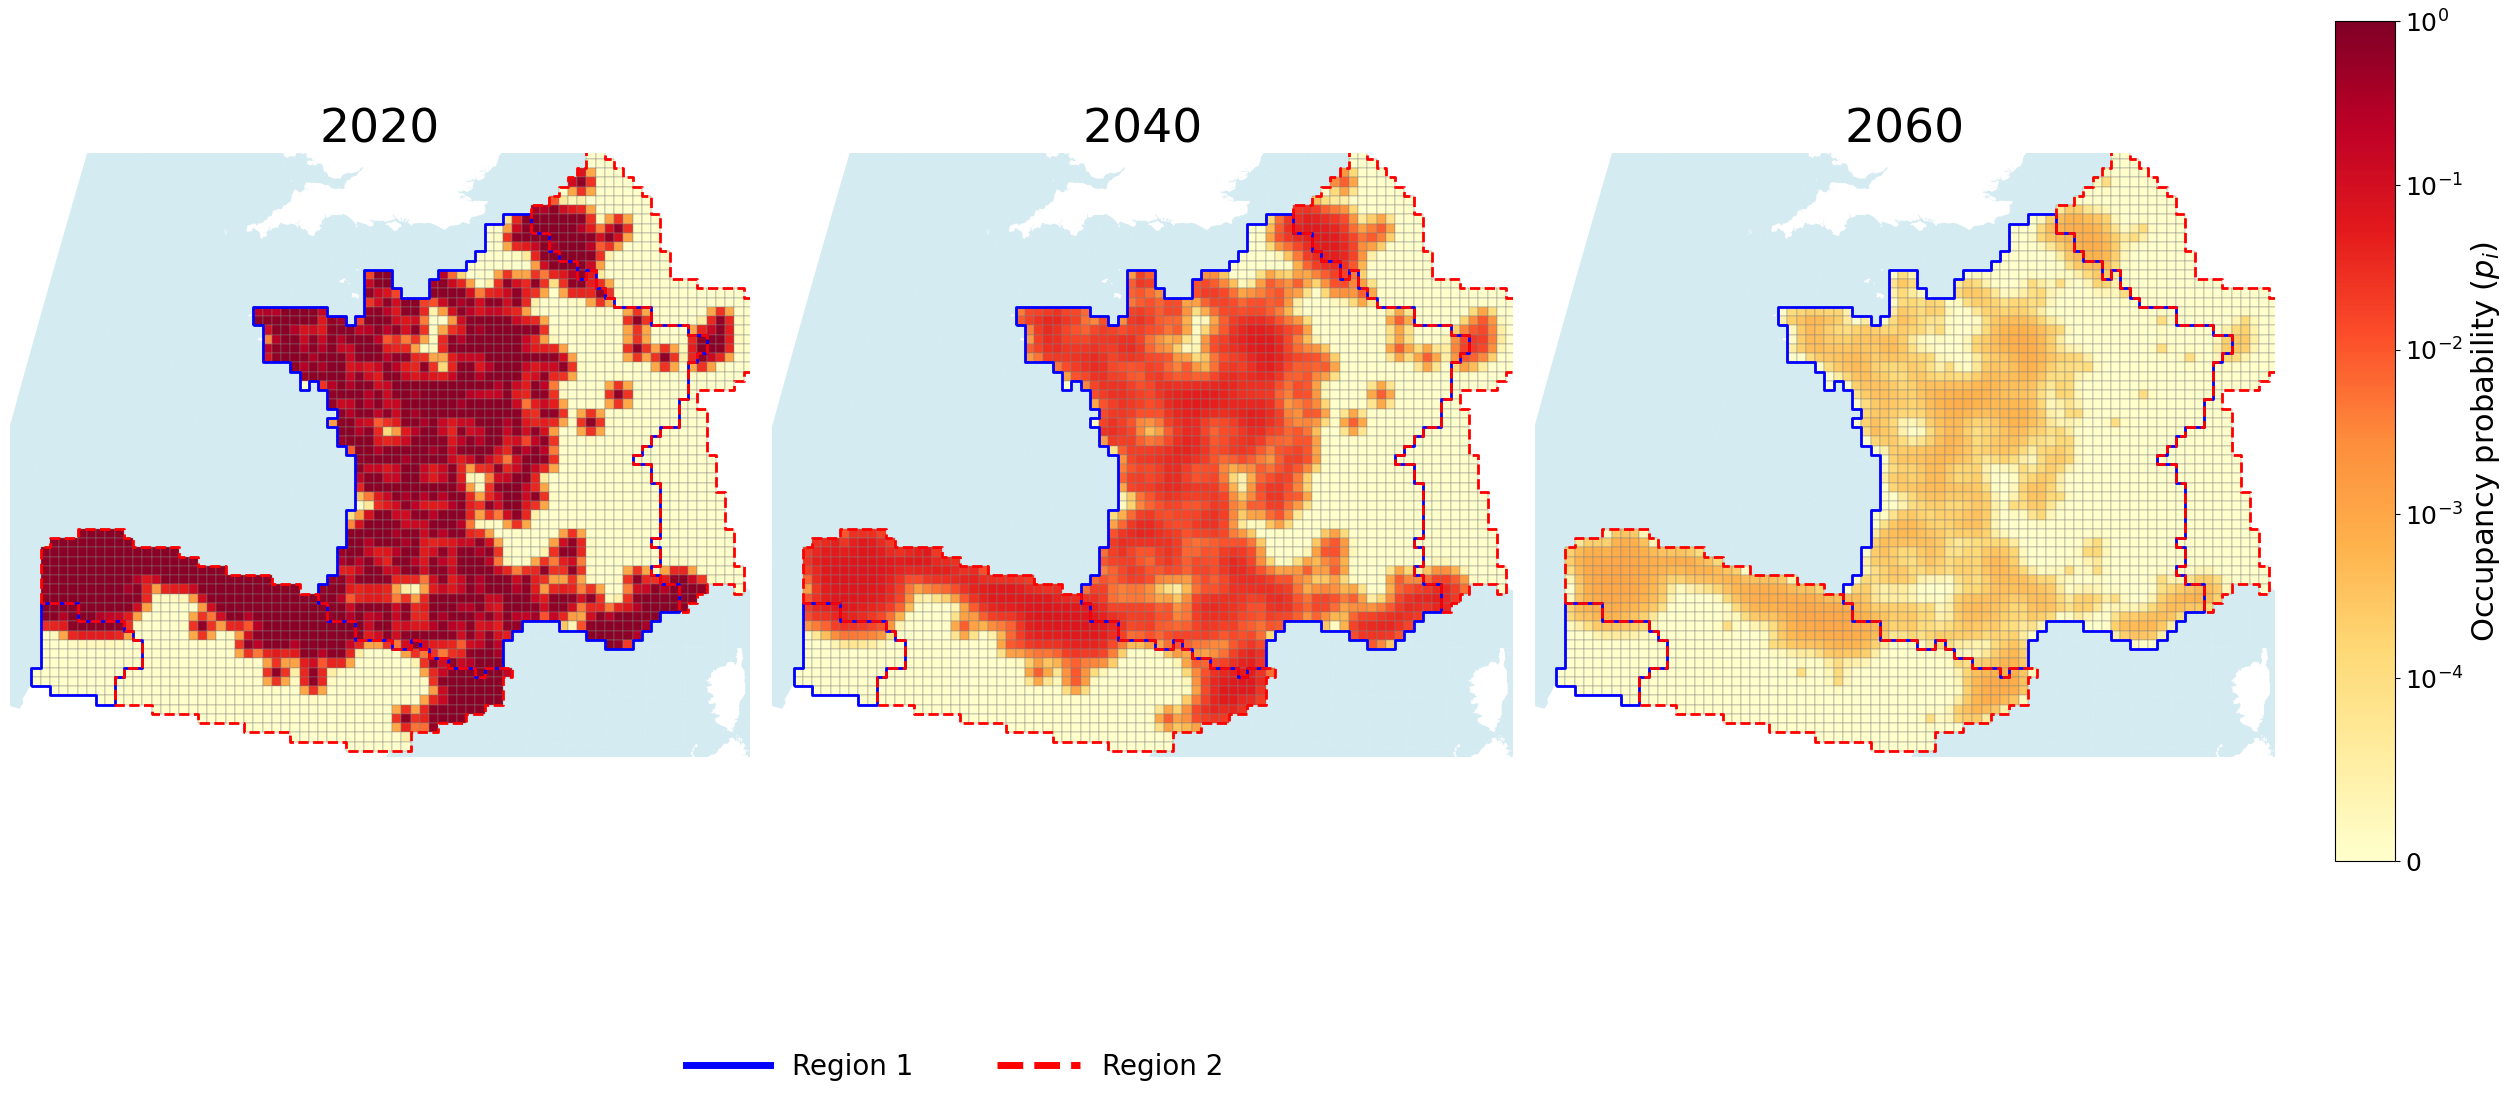

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

years = [2020, 2040, 2060]

region_boundaries = (
    patches[
        patches["region"].isin([1, 2])
    ]
    .dissolve(by="region")
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(30, 14)
)

axes = axes.flatten()

xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.SymLogNorm(linthresh=1e-4, vmin=0, vmax=1)
cmap = "YlOrRd"

for ax, year in zip(axes, years):
    map_year = map_d2_gs_r1_only[
        map_d2_gs_r1_only["year"] == year
    ].copy()

    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.3,
        zorder=3
    )

    region_boundaries.loc[[1]].boundary.plot(
        ax=ax,
        color="blue",
        linewidth=2,
        zorder=4
    )

    region_boundaries.loc[[2]].boundary.plot(
        ax=ax,
        color="red",
        linewidth=2,
        linestyle="--",
        zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(
        str(year),
        fontsize=34
    )

fig.subplots_adjust(
    right=0.88,
    bottom=0.10,
    wspace=0.03,
    hspace=0.03
)

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)
sm.set_array([])

cax = fig.add_axes([
    0.90,
    0.20,
    0.02,
    0.60
])

cbar = fig.colorbar(
    sm,
    cax=cax
)

cbar.set_label(
    r"Occupancy probability ($p_i$)",
    fontsize=22
)

cbar.ax.tick_params(
    labelsize=18
)

region_legend = [
    Line2D(
        [0], [0],
        color="blue",
        linewidth=5,
        label="Region 1"
    ),
    Line2D(
        [0], [0],
        color="red",
        linewidth=5,
        linestyle="--",
        label="Region 2"
    )
]

fig.legend(
    handles=region_legend,
    loc="lower center",
    bbox_to_anchor=(0.44, 0.025),
    ncol=2,
    prop={"size": 20},
    handlelength=3,
    columnspacing=3,
    frameon=False
)

plt.show()